# Filters, Thresholding, and Algorithms

This notebook shows how to apply image processing operations and run built-in algorithms.

In [1]:
!pip install medical-image-std

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.2 MB/s eta 0:00:00


In [5]:
!wget https://github.com/HamzaGbada/dicomPreProcess/blob/master/data/20587054.dcm

--2026-04-20 15:02:02--  https://github.com/HamzaGbada/dicomPreProcess/blob/master/data/20587054.dcm
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘20587054.dcm’

20587054.dcm            [ <=>                ] 215.86K  --.-KB/s    in 0.02s   

2026-04-20 15:02:03 (8.49 MB/s) - ‘20587054.dcm’ saved [221036]



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from medical_image import (
    DicomImage,
    Filters,
    Threshold,
    MorphologyOperations,
    FrequencyOperations,
    Metrics,
)

In [8]:
img = DicomImage("/content/1-1.dcm")
img.load()

print(f"Image: {img.width}x{img.height}")

Image: 2671x5101


## 1. Gaussian Filter

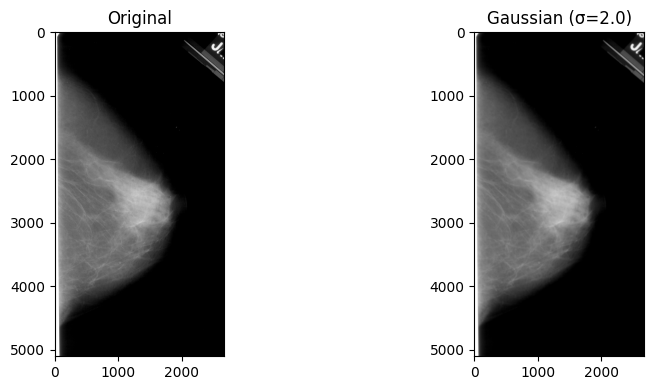

In [10]:
output = img.clone()
Filters.gaussian_filter(img, output, sigma=5.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Gaussian (σ=2.0)")
plt.tight_layout()
plt.show()

## 2. Median Filter

TypeError: Invalid shape (1, 5101, 2671) for image data

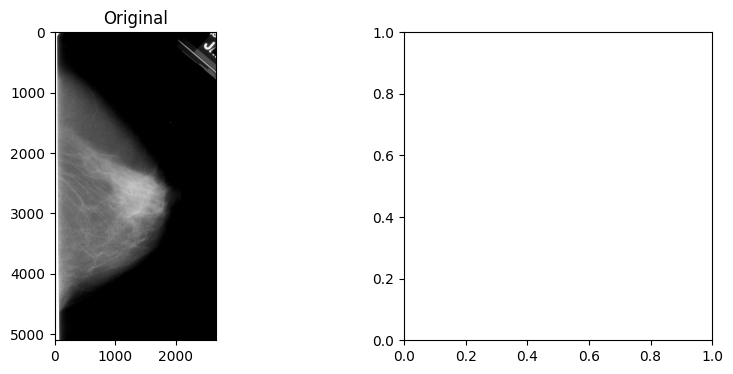

In [11]:
output = img.clone()
Filters.median_filter(img, output, size=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Median (size=5)")
plt.tight_layout()
plt.show()

## 3. Difference of Gaussians (DoG)

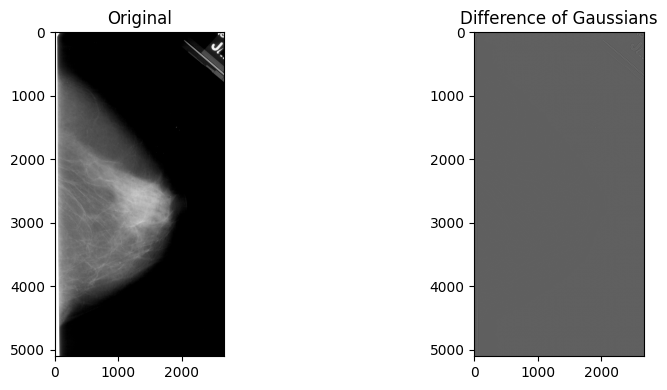

In [18]:
output = img.clone()
Filters.difference_of_gaussian(img, output, low_sigma=1.0, high_sigma=2.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Difference of Gaussians")
plt.tight_layout()
plt.show()

## 4. Gamma Correction

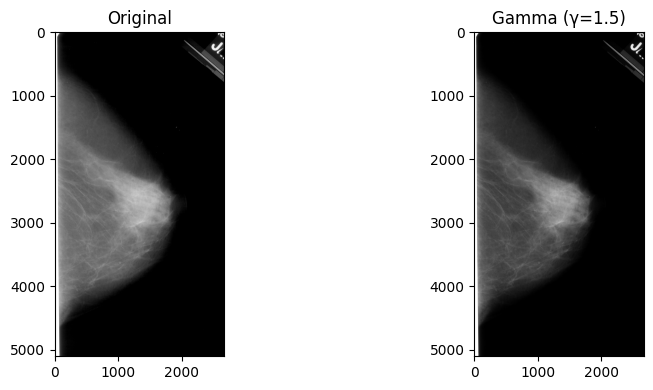

In [19]:
output = img.clone()
Filters.gamma_correction(img, output, gamma=1.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.numpy(), cmap="gray")
axes[1].set_title("Gamma (γ=1.5)")
plt.tight_layout()
plt.show()

## 5. Otsu Thresholding

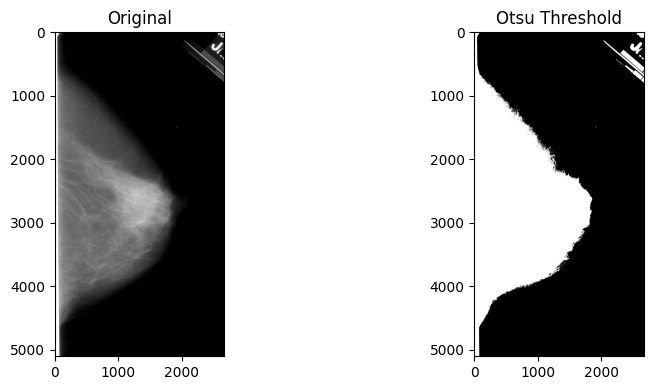

In [20]:
output = img.clone()
Threshold.otsu_threshold(img, output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Otsu Threshold")
plt.tight_layout()
plt.show()

## 6. Sauvola Thresholding (Adaptive)

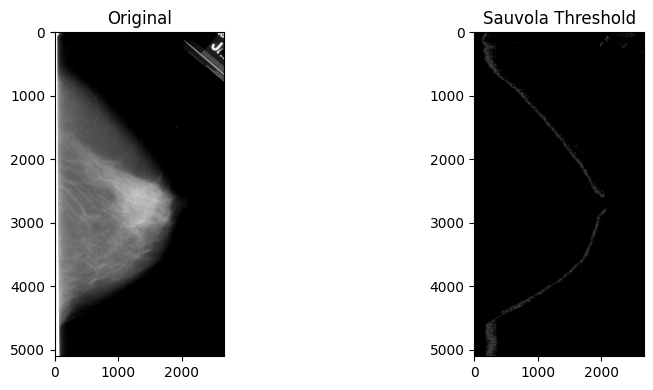

In [21]:
output = img.clone()
Threshold.sauvola_threshold(img, output, window_size=25, k=0.2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Sauvola Threshold")
plt.tight_layout()
plt.show()

## 7. Morphology Operations

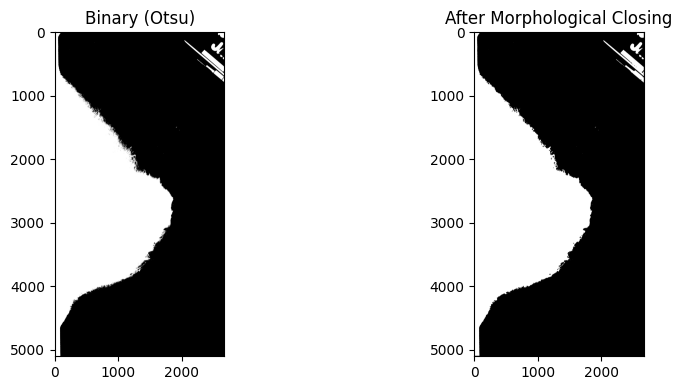

In [22]:
# First binarize, then apply morphological closing
binary = img.clone()
Threshold.otsu_threshold(img, binary)

closed = binary.clone()
MorphologyOperations.morphology_closing(binary, closed, kernel_size=7)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(binary.pixel_data.cpu().numpy(), cmap="gray")
axes[0].set_title("Binary (Otsu)")
axes[1].imshow(closed.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("After Morphological Closing")
plt.tight_layout()
plt.show()

## 8. Top-Hat Transform

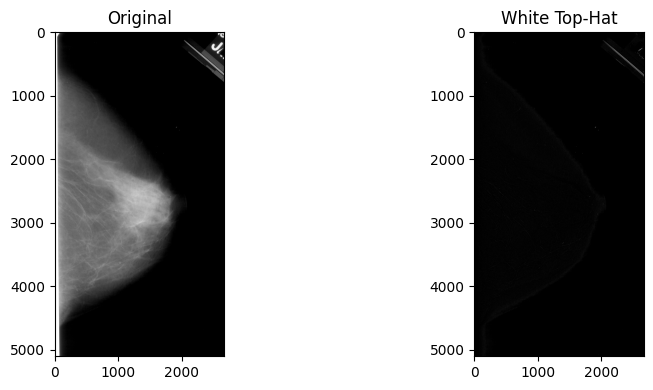

In [23]:
output = img.clone()
MorphologyOperations.white_top_hat(img, output, radius=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("White Top-Hat")
plt.tight_layout()
plt.show()

## 9. FFT (Frequency Domain)

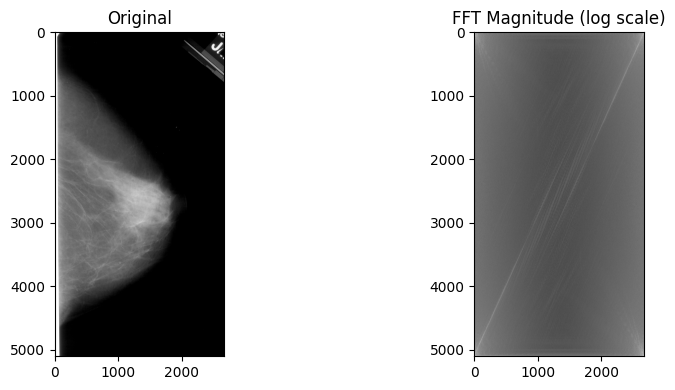

In [24]:
output = img.clone()
FrequencyOperations.fft(img, output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.log1p(np.abs(output.pixel_data.numpy())), cmap="gray")
axes[1].set_title("FFT Magnitude (log scale)")
plt.tight_layout()
plt.show()

## 10. Image Metrics

In [12]:
blurred = img.clone()
Filters.gaussian_filter(img, blurred, sigma=3.0)

entropy = Metrics.entropy(img)
mi = Metrics.mutual_information(img, blurred)

print(f"Entropy of original: {entropy}")
print(f"Mutual information (original vs blurred): {mi}")

NotImplementedError: "max_all" not implemented for 'UInt16'

## 11. Built-in Algorithms

The framework provides several complete algorithms that chain multiple operations.

In [13]:
import torch
from medical_image import FebdsAlgorithm, KMeansAlgorithm, FCMAlgorithm, TopHatAlgorithm

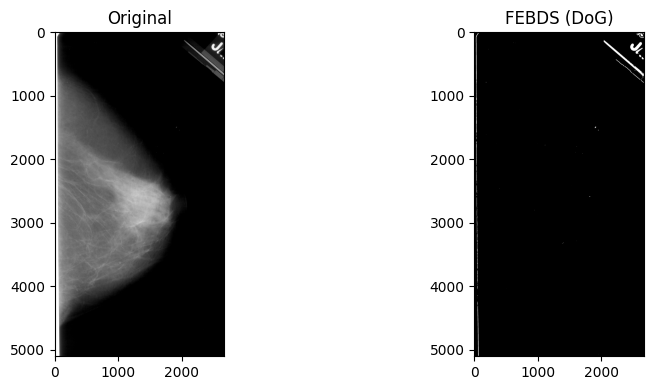

In [14]:
# FEBDS Algorithm (Difference of Gaussians variant)
img_t = img.clone()
if not isinstance(img_t.pixel_data, torch.Tensor):
    img_t.pixel_data = torch.from_numpy(img_t.pixel_data).float()

output = img_t.clone()
algo = FebdsAlgorithm(method="dog", device="cpu")
algo(image=img_t, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(
    output.pixel_data.detach().cpu().numpy().reshape(img.height, img.width), cmap="gray"
)
axes[1].set_title("FEBDS (DoG)")
plt.tight_layout()
plt.show()

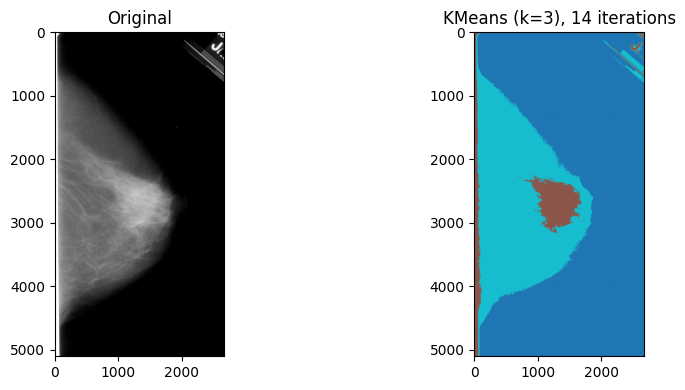

In [15]:
# KMeans Clustering
output = img.clone()
kmeans = KMeansAlgorithm(k=3, device="cpu")
kmeans(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(kmeans.labels.numpy(), cmap="tab10")
axes[1].set_title(f"KMeans (k=3), {kmeans.n_iter} iterations")
plt.tight_layout()
plt.show()

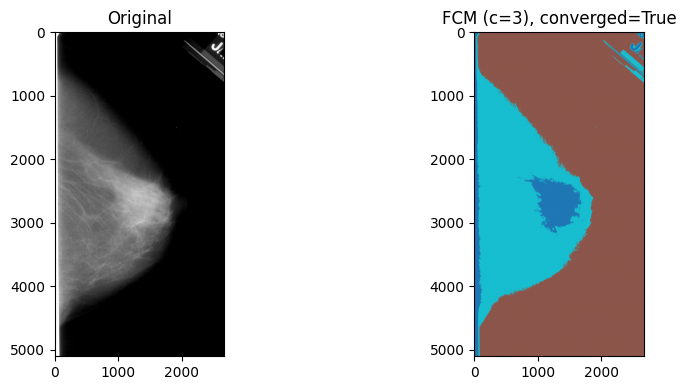

In [16]:
# Fuzzy C-Means
output = img.clone()
fcm = FCMAlgorithm(c=3, device="cpu")
fcm(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(fcm.labels.numpy(), cmap="tab10")
axes[1].set_title(f"FCM (c=3), converged={fcm.converged}")
plt.tight_layout()
plt.show()

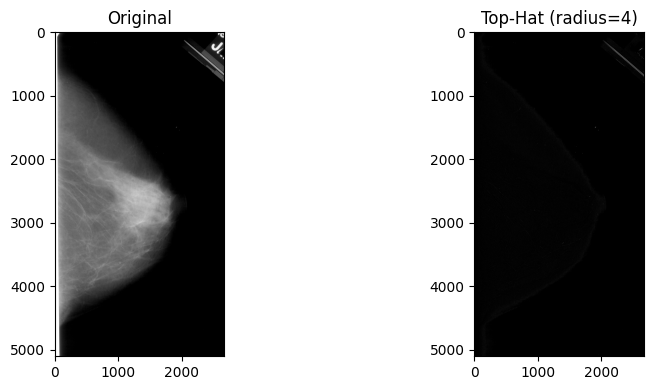

In [17]:
# Top-Hat Algorithm
output = img.clone()
tophat = TopHatAlgorithm(radius=4, device="cpu")
tophat(image=img, output=output)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.pixel_data.numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(output.pixel_data.cpu().numpy(), cmap="gray")
axes[1].set_title("Top-Hat (radius=4)")
plt.tight_layout()
plt.show()